# **Predicción de Cancelación (Churn) Telecom X – Parte 2**

## **📣 Historia del Desafío**

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

## **🎯 Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

## **🧠 Objetivos del Desafío**

- Preparar los datos para el modelado (tratamiento, codificación, normalización).

- Realizar análisis de correlación y selección de variables.

- Entrenar dos o más modelos de clasificación.

- Evaluar el rendimiento de los modelos con métricas.

- Interpretar los resultados, incluyendo la importancia de las variables.

- Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

## **🧰 Lo que vas a practicar**

✅ Preprocesamiento de datos para Machine Learning

✅ Construcción y evaluación de modelos predictivos

✅ Interpretación de resultados y entrega de insights

✅ Comunicación técnica con enfoque estratégico



### **I. Preparación de los Datos**

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Carga y limpieza inicial
df_telecom = pd.read_csv('/content/TelecomX_CleanData.csv')

# Eliminamos identificadores y variables con baja relevancia estadística en un solo paso
# Se incluyen Gender y PhoneService por los resultados de significancia previos
to_drop = ['CustomerID', 'Gender', 'PhoneService']
df_telecom.drop(columns=[c for c in to_drop if c in df_telecom.columns], inplace=True)

In [29]:
df_telecom.head()

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [30]:
# 2. Encoding de variables categóricas y definición del target
# Usamos drop_first=True para evitar la trampa de las variables ficticias (dummy trap)
X = pd.get_dummies(df_telecom.drop("Churn", axis=1), drop_first=True)
y = df_telecom["Churn"].map({'Yes': 1, 'No': 0})

print(f"Dimensiones finales del set de características: {X.shape}")
print(f"Distribución del Target (%):\n{y.value_counts(normalize=True) * 100}")

Dimensiones finales del set de características: (7043, 22)
Distribución del Target (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


### **II. Correlación y Selección de Variables**

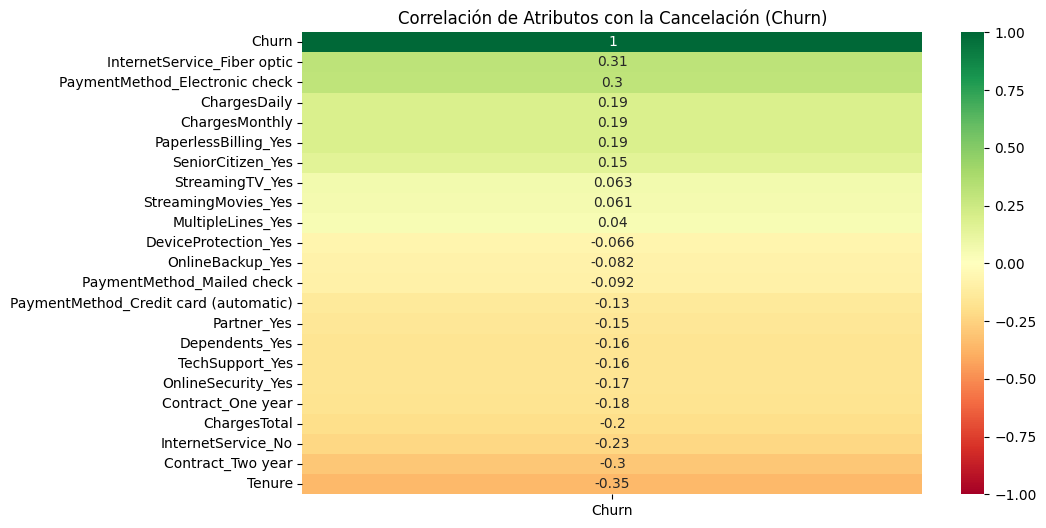

In [31]:
# 3. Análisis de Correlación dirigida al Churn
plt.figure(figsize=(10, 6))
# Creamos un dataframe temporal para no afectar las variables X e y originales
corr_churn = X.assign(Churn=y).corr()[['Churn']].sort_values(by='Churn', ascending=False)

sns.heatmap(corr_churn, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title("Correlación de Atributos con la Cancelación (Churn)")
plt.show()

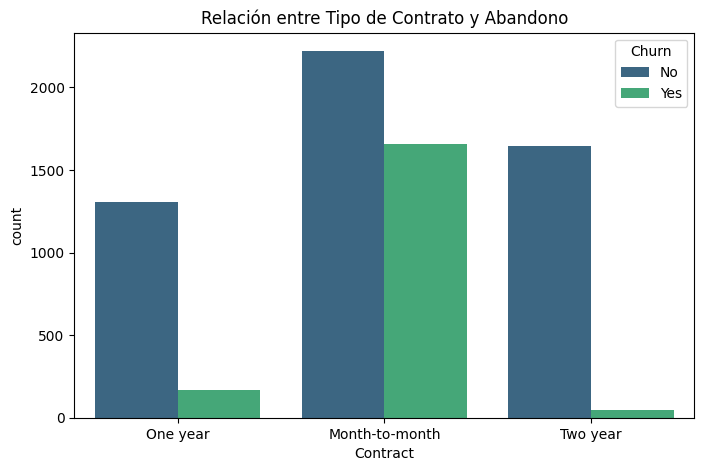

In [32]:
# 4. Análisis de Contratos (Variable crítica identificada)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_telecom, x='Contract', hue='Churn', palette='viridis')
plt.title("Relación entre Tipo de Contrato y Abandono")
plt.show()

### **III. Modelado Predictivo**

In [33]:
# 5. División del dataset (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [34]:
# 6. Estandarización (Fundamental para la convergencia de la Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# 7. Entrenamiento de modelos
# Modelo A: Logística con ajuste de pesos para manejar el desbalance de clases
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [36]:
# Modelo B: Random Forest (No requiere escalado, usamos datos originales)
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)


--- Regresión Logística (Balanced) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



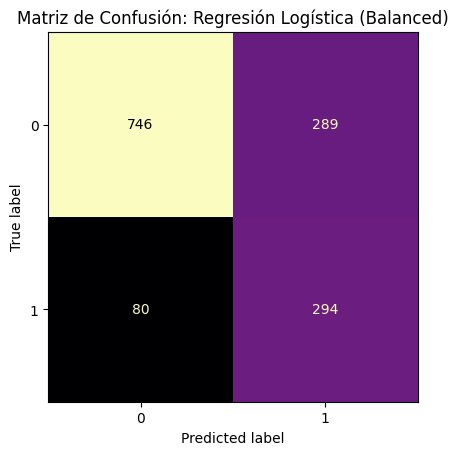


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



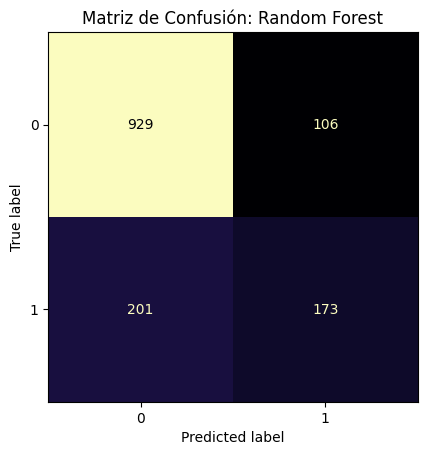

In [37]:
# 8. Evaluación detallada
modelos = {
    "Regresión Logística (Balanced)": (log_model, X_test_scaled),
    "Random Forest": (rf_model, X_test)
}

for nombre, (model, data) in modelos.items():
    preds = model.predict(data)
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, preds))

    # Matriz de confusión con estilo limpio
    ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='magma', colorbar=False)
    plt.title(f"Matriz de Confusión: {nombre}")
    plt.grid(False)
    plt.show()

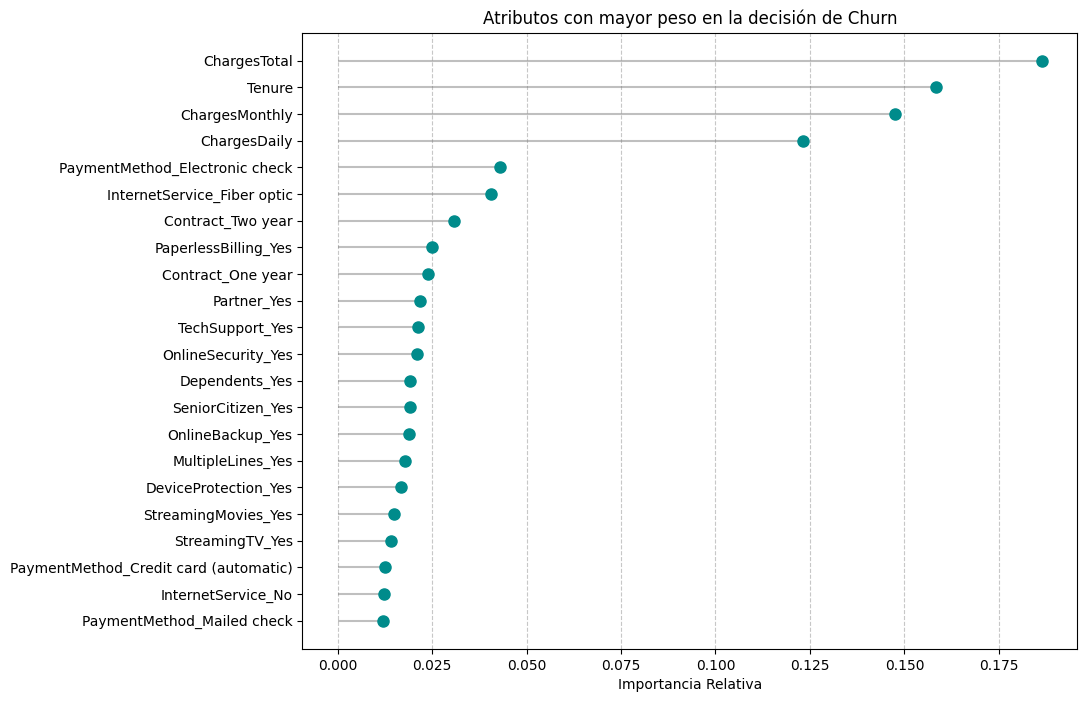

In [38]:
# 9. Visualización de Importancia (Lollipop Plot)
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(10, 8))
plt.hlines(y=importancias.index, xmin=0, xmax=importancias.values, color='gray', alpha=0.5)
plt.plot(importancias.values, importancias.index, "o", markersize=8, color='darkcyan')
plt.title("Atributos con mayor peso en la decisión de Churn")
plt.xlabel("Importancia Relativa")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **IV. Conclusiones**

## **Informe de Análisis de Cancelación de Clientes: Telecom X**

Este informe detalla el proceso de análisis predictivo y las conclusiones obtenidas para identificar por qué los clientes abandonan la compañía y qué medidas se pueden tomar al respecto.

### **1. Preparación y Modelado de Datos**
- Curación: Se eliminaron datos irrelevantes como CustomerID, Gender y PhoneService.

- Encoding: Se transformaron variables categóricas a numéricas mediante One-Hot Encoding para que fueran procesables por los algoritmos.

- Balanceo: Se identificó un desbalanceo de clases (~73% No Churn vs ~27% Churn) y se corrigió en la Regresión Logística ajustando los pesos de clase.

- Modelado: Se compararon dos modelos principales: Regresión Logística y Random Forest. La Regresión Logística resultó superior para el negocio al lograr un Recall del 79% en la detección de clientes que cancelan.

### **2. Factores Clave de Cancelación**
- Tipo de Contrato: Es el factor más influyente. Los contratos "mes a mes" tienen una tasa de fuga del 42.7%, mientras que los de dos años solo un 2.8%.

- Servicios de Valor: La ausencia de Seguridad en Línea (OnlineSecurity) y Soporte Técnico (TechSupport) está fuertemente ligada al abandono.

- Método de Pago: El uso de Cheque Electrónico presenta una alta correlación con el Churn.

- Cargos Mensuales: Los clientes con cargos elevados tienen mayor probabilidad de irse si no perciben beneficios adicionales.

### **3. Estrategias de Retención Propuestas**
- Incentivos de Migración: Ofrecer descuentos o beneficios para que los clientes con contratos mensuales pasen a planes de 1 o 2 años.

- Paquetes de Fidelización: Incluir seguridad y soporte técnico de forma gratuita o a precio reducido en los planes básicos.

- Segmentación de Adultos Mayores: Implementar programas de atención específica para el segmento de Senior Citizen, que presenta alta sensibilidad.

- Automatización de Pagos: Fomentar el cambio de cheque electrónico a pago automático mediante bonificaciones en la factura.

### **4. Conclusiones**

El éxito en la retención de Telecom X no depende solo de bajar precios, sino de mover al cliente hacia contratos de mayor duración y asegurar que utilicen los servicios de seguridad y soporte, los cuales han demostrado ser los mejores escudos contra la competencia. El modelo de Regresión Logística implementado servirá como un sistema de alerta temprana para aplicar estas estrategias antes de que el cliente tome la decisión final de retiro.